<a href="https://colab.research.google.com/github/VamsiKrishna-05/Crop-Recommendation-CCPS/blob/main/MSVM_DAG_FFO_CropRecommendation.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 🌾 MSVM-DAG-FFO: Crop Recommendation System
### A Novel DAG-Based SVM with Fruit Fly Optimization on Soil & Climate Features

**Authors:** VamsiKrishna B · Surendar P · Florence Gnana Poovathy J  
**Institution:** Vellore Institute of Technology, Chennai

---
### 📋 Notebook Overview
This notebook implements the **complete MSVM-DAG-FFO pipeline** as described in the paper, with every step separated into clearly labelled cells:

| # | Section | What it does |
|---|---------|-------------|
| 1 | Setup | Install & import all dependencies |
| 2 | Data Loading | Load dataset, audit quality |
| 3 | EDA | Class distribution, feature distributions, correlation heatmap |
| 4 | Preprocessing | Leakage-free split → scale → SMOTE |
| 5 | Baseline Models | 9 baselines under identical preprocessing |
| 6 | FFO | Fruit Fly Optimization to tune C & γ |
| 7 | DAG-SVM | Train 66 binary SVMs in DAG structure |
| 8 | Evaluation | Accuracy, F1, confusion matrix, ROC/AUC |
| 9 | Ablation | Component-by-component contribution |
| 10 | Summary | Final comparison table + bar chart |

> **Dataset required:** Upload `Crop_Recommendation_using_Soil_Properties_and_Weather_Prediction.csv`  
> to the Colab session (Files panel on the left) before running Cell 2.


---
## 1 · Setup & Installations
> Run once per Colab session. Installs imbalanced-learn and lightgbm.


In [37]:
# ── Install extra packages not available by default in Colab ──────────
!pip install imbalanced-learn lightgbm --quiet
print('✅ Packages ready')


✅ Packages ready


In [38]:
# ── Core imports ──────────────────────────────────────────────────────
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Preprocessing
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from imblearn.over_sampling import SMOTE

# Metrics
from sklearn.metrics import (
    accuracy_score, f1_score, precision_score, recall_score,
    confusion_matrix, ConfusionMatrixDisplay,
    classification_report, cohen_kappa_score,
    matthews_corrcoef, roc_curve, auc
)
from sklearn.preprocessing import label_binarize

# Baseline models
from sklearn.svm import SVC
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.multiclass import OneVsRestClassifier
from imblearn.ensemble import BalancedRandomForestClassifier, EasyEnsembleClassifier
import lightgbm as lgb

# Reproducibility
SEED = 42
np.random.seed(SEED)

# Plot style
plt.rcParams.update({'font.family':'DejaVu Sans','axes.spines.top':False,
                     'axes.spines.right':False,'figure.dpi':110})
PALETTE = ['#1A5276','#0E6655','#BA4A00','#7B241C','#1A5276','#6C3483']
print('✅ All imports successful')


✅ All imports successful


---
## 2 · Data Loading & Quality Audit
> Load the CSV, inspect shape, dtypes, missing values, and class distribution.


In [39]:
# ── Load dataset ─────────────────────────────────────────────────────
# If running in Colab: upload the CSV using the Files panel on the left,
# or uncomment the drive.mount() block below.

# from google.colab import drive
# drive.mount('/content/drive')
# CSV_PATH = '/content/drive/MyDrive/your_folder/Crop_Recommendation_..._Prediction.csv'

CSV_PATH = 'Crop Recommendation using Soil Properties and Weather Prediction.csv'

df = pd.read_csv(CSV_PATH)
print(f'Dataset shape : {df.shape}  ({df.shape[0]} rows × {df.shape[1]} columns)')
print(f'Label column  : label  |  unique classes: {df["label"].nunique()}')
print(f'Missing values: {df.isnull().sum().sum()} total')
df.head()


Dataset shape : (3867, 29)  (3867 rows × 29 columns)
Label column  : label  |  unique classes: 12
Missing values: 0 total


,Soilcolor,Ph,K,P,N,Zn,S,QV2M-W,QV2M-Sp,QV2M-Su,...,PRECTOTCORR-W,PRECTOTCORR-Sp,PRECTOTCORR-Su,PRECTOTCORR-Au,WD10M,GWETTOP,CLOUD_AMT,WS2M_RANGE,PS,label
0,Yellowish brown,5.81,738.231,5.401,0.23,2.976000,13.816,7.993333,10.456667,11.963333,...,2.073333,5.27,12.303333,5.27,3.44,0.73,56.57,6.24,77.03,Barley
1,Yellowish brown,5.43,606.382,10.478,0.23,3.077000,16.421,7.993333,10.456667,11.963333,...,2.073333,5.27,12.303333,5.27,3.44,0.73,56.57,6.24,77.03,Barley
2,brown,5.41,386.580,6.847,0.23,6.611000,16.557,7.993333,10.456667,11.963333,...,2.073333,5.27,12.303333,5.27,3.44,0.73,56.57,6.24,77.03,Barley
3,red,5.65,207.086,3.418,0.23,0.460181,16.075,7.993333,10.456667,11.963333,...,2.073333,5.27,12.303333,5.27,3.44,0.73,56.57,6.24,77.03,Barley
4,red,5.27,317.357,39.282,0.23,2.743000,12.558,7.993333,10.456667,11.963333,...,2.073333,5.27,12.303333,5.27,3.44,0.73,56.57,6.24,77.03,Barley


In [40]:
# ── Data types overview ──────────────────────────────────────────────
print('--- Dtypes ---')
print(df.dtypes)
print()
print('--- Categorical columns ---')
for col in df.select_dtypes(include='object').columns:
    print(f'  {col}: {df[col].nunique()} unique values')


--- Dtypes ---
Soilcolor          object
Ph                float64
K                 float64
P                 float64
N                 float64
Zn                float64
S                 float64
QV2M-W            float64
QV2M-Sp           float64
QV2M-Su           float64
QV2M-Au           float64
T2M_MAX-W         float64
T2M_MAX-Sp        float64
T2M_MAX-Su        float64
T2M_MAX-Au        float64
T2M_MIN-W         float64
T2M_MIN-Sp        float64
T2M_MIN-Su        float64
T2M_MIN-Au        float64
PRECTOTCORR-W     float64
PRECTOTCORR-Sp    float64
PRECTOTCORR-Su    float64
PRECTOTCORR-Au    float64
WD10M             float64
GWETTOP           float64
CLOUD_AMT         float64
WS2M_RANGE        float64
PS                float64
label              object
dtype: object

--- Categorical columns ---
  Soilcolor: 45 unique values
  label: 12 unique values


Class distribution:
label
Teff          1260
Maize          732
Wheat          715
Barley         503
Bean           253
Pea             94
Sorghum         72
Dagussa         71
Niger seed      64
Potato          48
Red Pepper      29
Fallow          26

Imbalance ratio  : 48.46:1  (majority=Teff: 1260  |  minority=Fallow: 26)


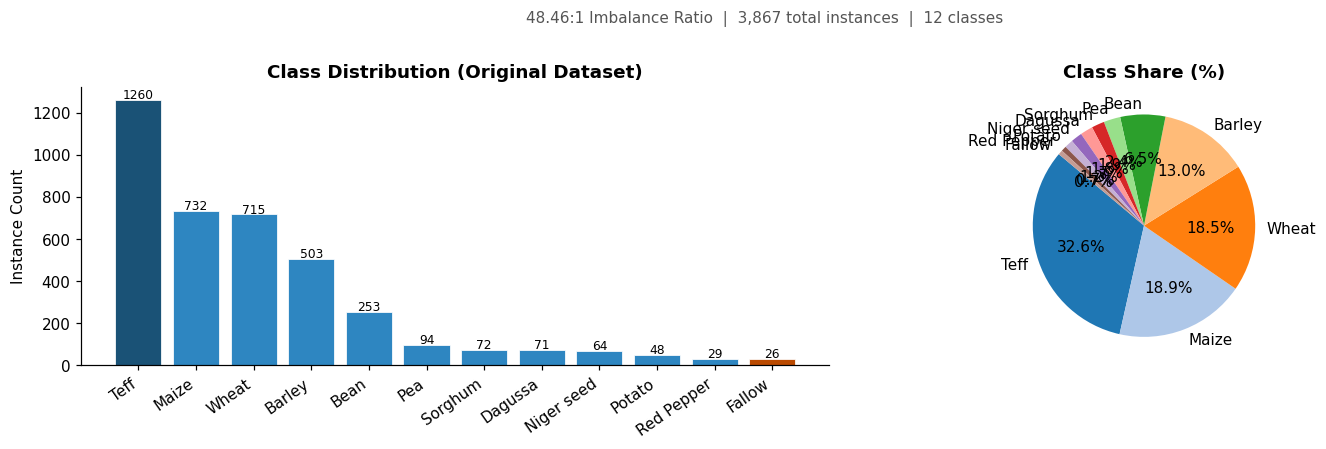

In [41]:
# ── Class distribution ───────────────────────────────────────────────
dist = df['label'].value_counts()
print('Class distribution:')
print(dist.to_string())
print()
majority = dist.max(); minority = dist.min()
print(f'Imbalance ratio  : {majority/minority:.2f}:1  (majority={dist.idxmax()}: {majority}  |  minority={dist.idxmin()}: {minority})')

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Bar chart
colors = ['#1A5276' if v == majority else '#BA4A00' if v == minority else '#2E86C1'
          for v in dist.values]
axes[0].bar(dist.index, dist.values, color=colors, edgecolor='white', linewidth=0.5)
axes[0].set_title('Class Distribution (Original Dataset)', fontweight='bold')
axes[0].set_ylabel('Instance Count')
axes[0].set_xticklabels(dist.index, rotation=35, ha='right')
for i, v in enumerate(dist.values):
    axes[0].text(i, v+8, str(v), ha='center', fontsize=8)

# Pie chart
axes[1].pie(dist.values, labels=dist.index, autopct='%1.1f%%',
            startangle=140, colors=plt.cm.tab20.colors[:len(dist)])
axes[1].set_title('Class Share (%)', fontweight='bold')

plt.suptitle(f'48.46:1 Imbalance Ratio  |  3,867 total instances  |  12 classes',
             fontsize=10, color='#555555', y=1.01)
plt.tight_layout(); plt.show()


---
## 3 · Exploratory Data Analysis (EDA)
> Feature distributions, soil colour breakdown, correlation heatmap, per-class box plots.


In [42]:
# ── 3a. Numeric summary ──────────────────────────────────────────────
print('Numeric feature summary (28 features across 4 domains):')
print(df.describe().T[['min','max','mean','std']].round(3))


Numeric feature summary (28 features across 4 domains):
                   min       max     mean      std
Ph               4.300     8.500    5.857    0.677
K               41.134  2119.000  324.285  202.250
P                0.000   782.000   11.350   34.142
N                0.000     0.696    0.179    0.066
Zn               0.100    45.500    1.774    1.461
S                0.050   118.347   11.312    5.542
QV2M-W           7.183     9.723    8.347    0.614
QV2M-Sp          7.650    10.703    9.083    0.791
QV2M-Su         10.477    13.853   12.232    0.895
QV2M-Au          9.070    12.800   10.991    0.994
T2M_MAX-W        9.030    30.827   25.558    4.250
T2M_MAX-Sp      25.147    33.973   29.804    2.318
T2M_MAX-Su      23.060    28.243   24.686    1.586
T2M_MAX-Au      20.617    26.520   23.282    1.610
T2M_MIN-W        2.053    11.390    6.659    1.933
T2M_MIN-Sp       4.817    15.657   10.346    2.305
T2M_MIN-Su       8.433    14.727   11.582    1.459
T2M_MIN-Au       3.980    

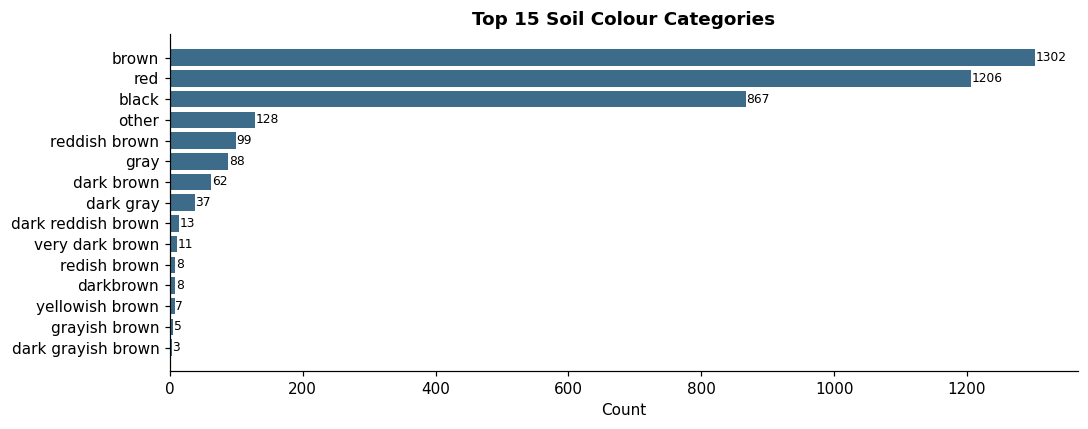

Total unique soil colour entries (raw): 45
Note: Case/whitespace inconsistencies will be handled by LabelEncoder after lowercasing.


In [43]:
# ── 3b. Soil colour distribution ─────────────────────────────────────
# Normalise case/whitespace for cleaner counts
soil_counts = df['Soilcolor'].str.lower().str.strip().value_counts().head(15)

fig, ax = plt.subplots(figsize=(10, 4))
ax.barh(soil_counts.index[::-1], soil_counts.values[::-1],
        color='#1A5276', alpha=0.85)
ax.set_xlabel('Count'); ax.set_title('Top 15 Soil Colour Categories', fontweight='bold')
for i, v in enumerate(soil_counts.values[::-1]):
    ax.text(v+1, i, str(v), va='center', fontsize=8)
plt.tight_layout(); plt.show()
print(f'Total unique soil colour entries (raw): {df["Soilcolor"].nunique()}')
print('Note: Case/whitespace inconsistencies will be handled by LabelEncoder after lowercasing.')


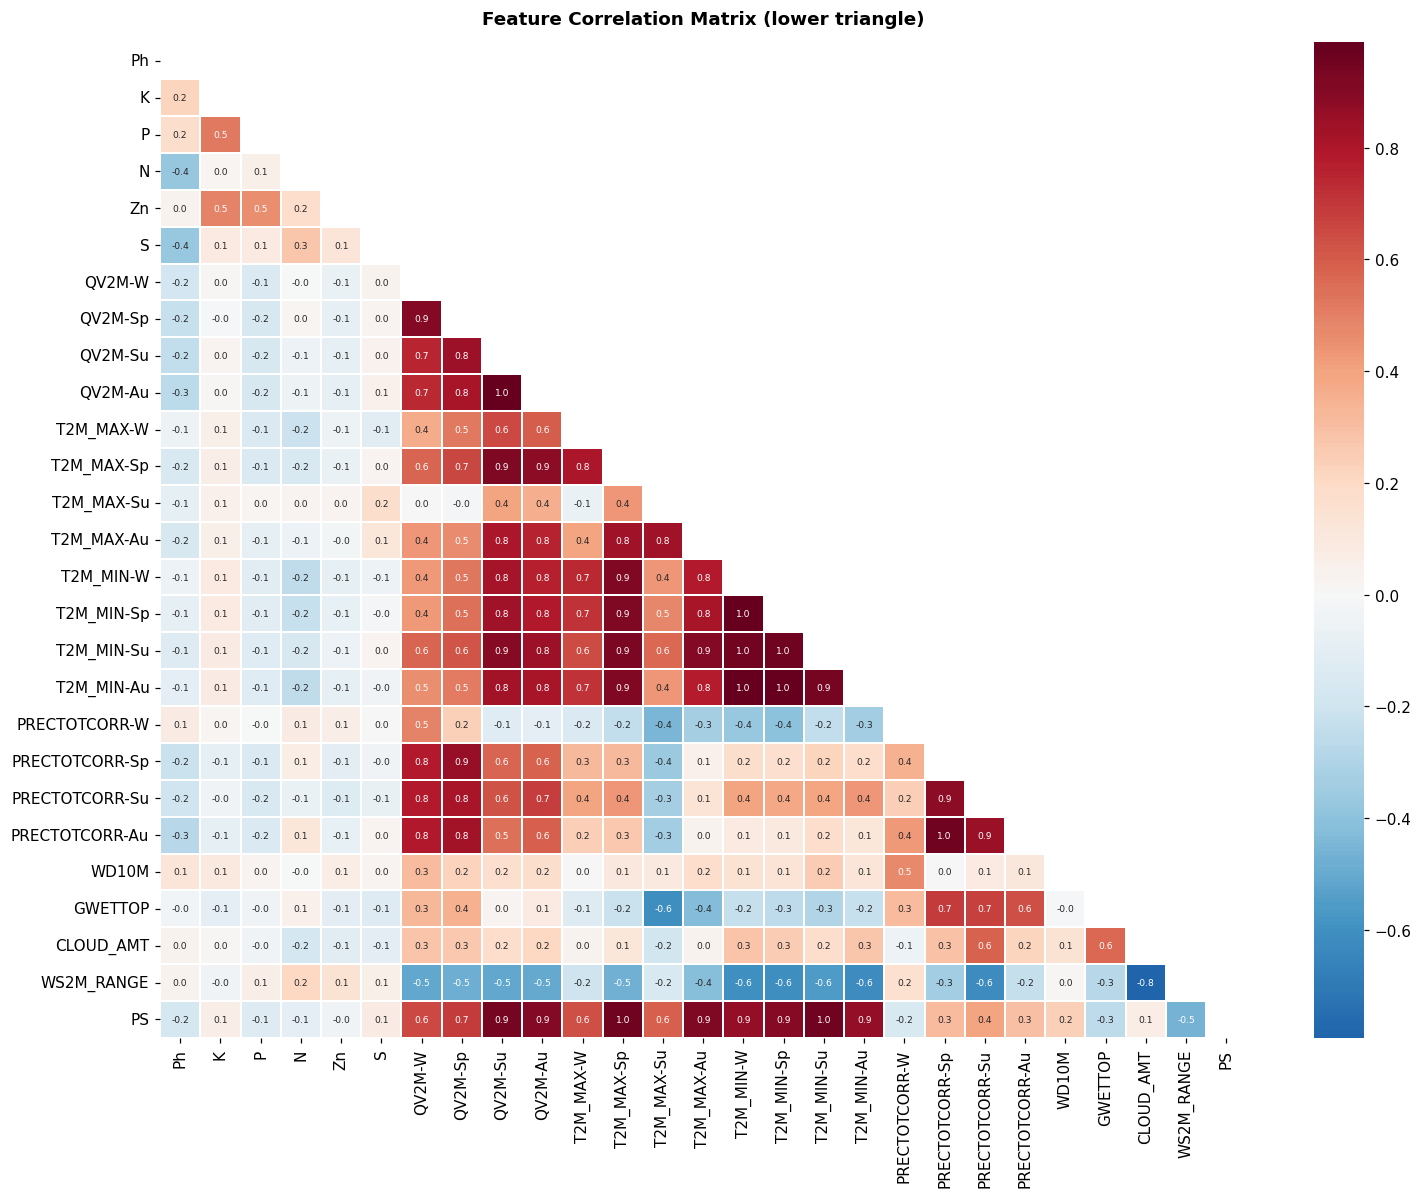

In [44]:
# ── 3c. Feature correlation heatmap ──────────────────────────────────
numeric_cols = df.select_dtypes(include='number').columns.tolist()
fig, ax = plt.subplots(figsize=(14, 11))
corr = df[numeric_cols].corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, cmap='RdBu_r', center=0,
            annot=True, fmt='.1f', annot_kws={'size':6},
            linewidths=0.3, ax=ax)
ax.set_title('Feature Correlation Matrix (lower triangle)', fontweight='bold', pad=12)
plt.tight_layout(); plt.show()


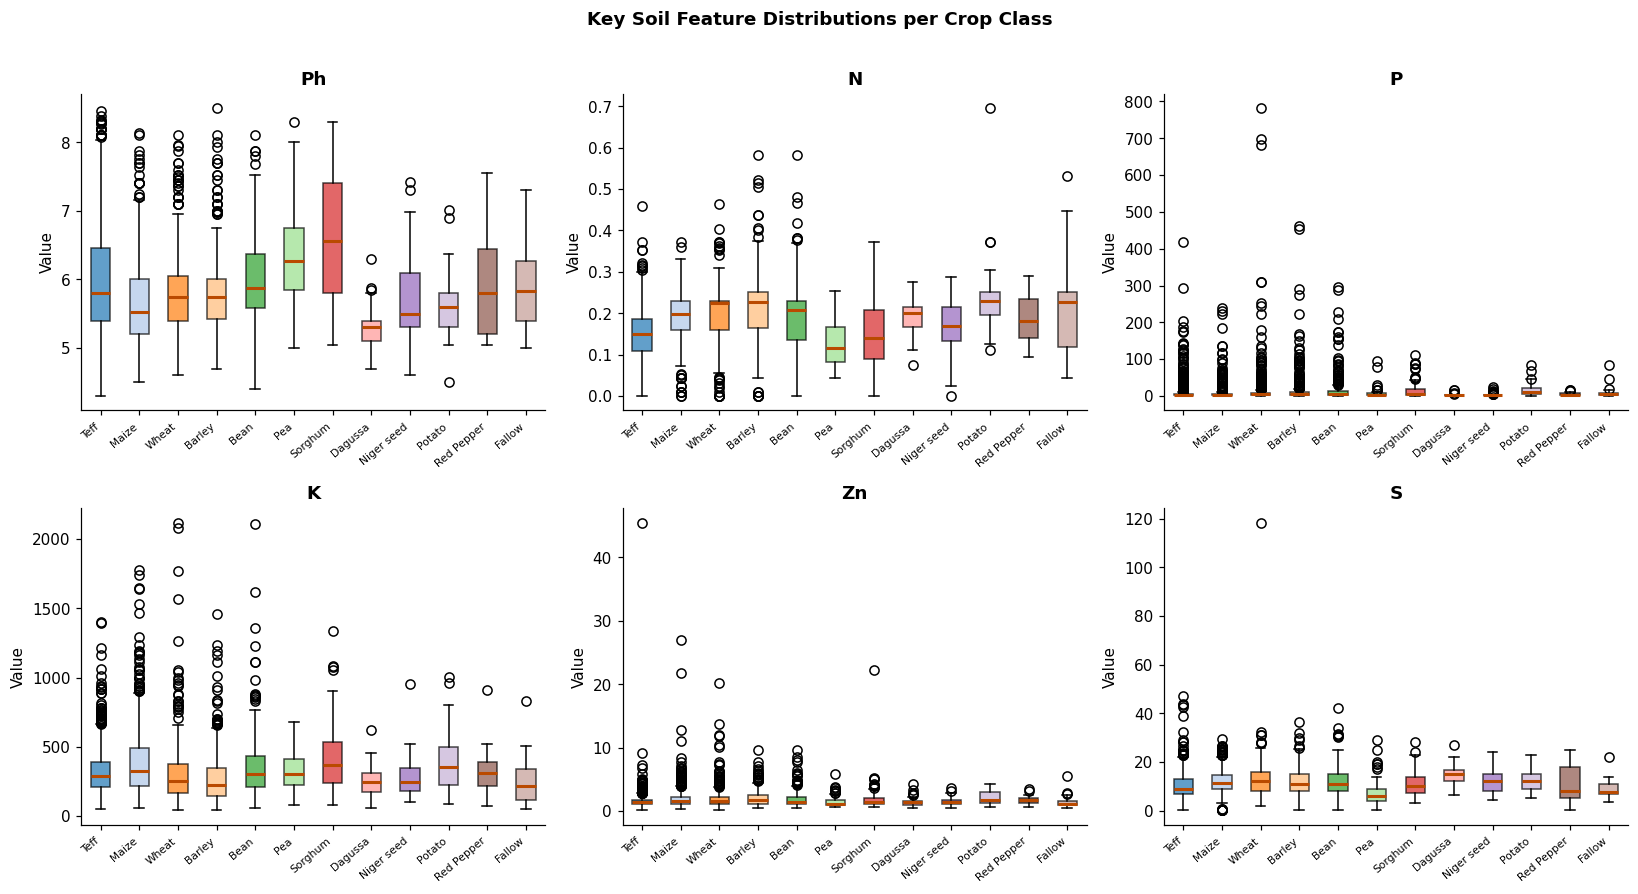

In [45]:
# ── 3d. Key soil feature distributions per crop ──────────────────────
key_features = ['Ph', 'N', 'P', 'K', 'Zn', 'S']
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
crop_order = df['label'].value_counts().index.tolist()

for ax, feat in zip(axes.flat, key_features):
    data_by_crop = [df[df['label']==c][feat].values for c in crop_order]
    bp = ax.boxplot(data_by_crop, patch_artist=True, notch=False,
                   medianprops={'color':'#BA4A00','lw':2})
    for patch, color in zip(bp['boxes'], plt.cm.tab20.colors[:len(crop_order)]):
        patch.set_facecolor(color); patch.set_alpha(0.7)
    ax.set_xticklabels(crop_order, rotation=40, ha='right', fontsize=7)
    ax.set_title(f'{feat}', fontweight='bold')
    ax.set_ylabel('Value')

plt.suptitle('Key Soil Feature Distributions per Crop Class', fontweight='bold', y=1.01)
plt.tight_layout(); plt.show()


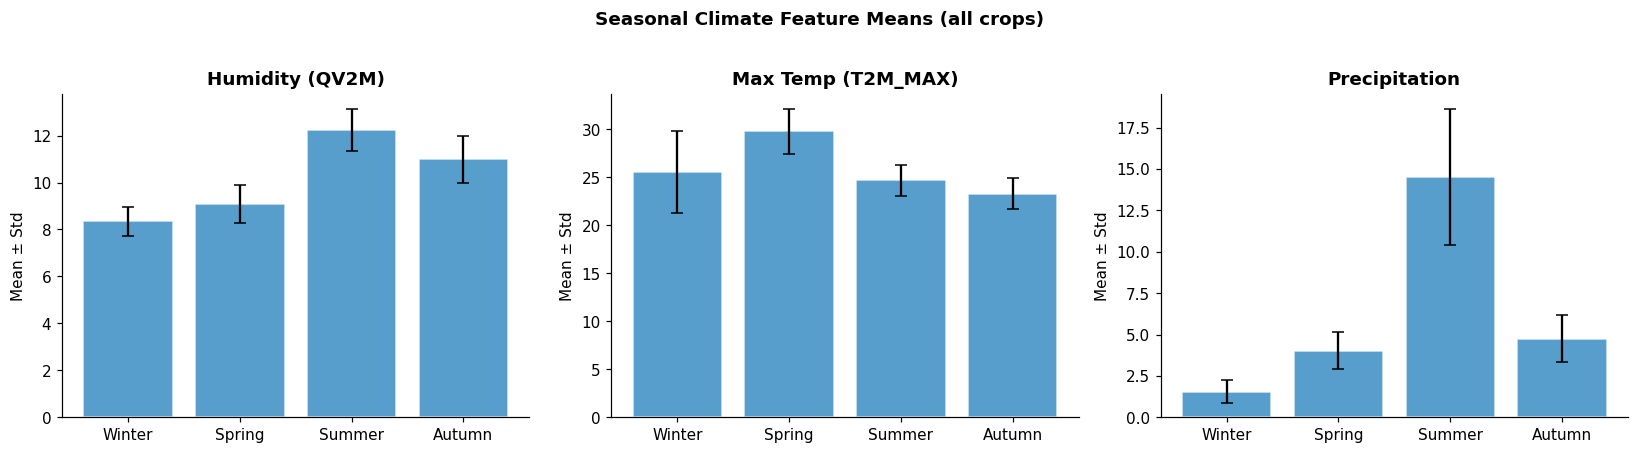

In [46]:
# ── 3e. Seasonal temperature & humidity overview ─────────────────────
climate_groups = {
    'Humidity (QV2M)':  ['QV2M-W','QV2M-Sp','QV2M-Su','QV2M-Au'],
    'Max Temp (T2M_MAX)': ['T2M_MAX-W','T2M_MAX-Sp','T2M_MAX-Su','T2M_MAX-Au'],
    'Precipitation':    ['PRECTOTCORR-W','PRECTOTCORR-Sp','PRECTOTCORR-Su','PRECTOTCORR-Au'],
}
season_labels = ['Winter','Spring','Summer','Autumn']

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, (title, cols) in zip(axes, climate_groups.items()):
    means = df[cols].mean().values
    stds  = df[cols].std().values
    xs = range(len(cols))
    ax.bar(xs, means, yerr=stds, color='#2E86C1', alpha=0.8,
           capsize=4, edgecolor='white')
    ax.set_xticks(xs); ax.set_xticklabels(season_labels)
    ax.set_title(title, fontweight='bold'); ax.set_ylabel('Mean ± Std')

plt.suptitle('Seasonal Climate Feature Means (all crops)', fontweight='bold', y=1.02)
plt.tight_layout(); plt.show()


---
## 4 · Leakage-Free Preprocessing Pipeline
> Critical: split FIRST, then scale on train only, then SMOTE on train only.


### ⚠️ Why preprocessing order matters

Many published implementations make a **data leakage mistake** by applying SMOTE or StandardScaler
to the full dataset before splitting. This inflates results because:
- **Scaler leakage**: test-set statistics influence the scale used during training.
- **SMOTE leakage**: synthetic minority samples generated from the full dataset can land
  in the test set, giving the model a "peek" at test distributions.

**Correct order (used here):**
```
1. Stratified 80/20 split  ← done first, on raw data
2. StandardScaler.fit() on X_train only
3. scaler.transform() on both X_train and X_test
4. SMOTE applied to X_train_scaled only
```


In [47]:
# ── Step 1: Encode categorical column ────────────────────────────────
df_clean = df.copy()

# Normalise soil colour (handles 45 inconsistent variants in dataset)
df_clean['Soilcolor'] = df_clean['Soilcolor'].str.lower().str.strip()
le_soil = LabelEncoder()
df_clean['Soilcolor'] = le_soil.fit_transform(df_clean['Soilcolor'])

# Encode target label — alphabetical: Barley=0 ... Wheat=11
le_label = LabelEncoder()
df_clean['label'] = le_label.fit_transform(df_clean['label'])
CLASS_NAMES = le_label.classes_
print('Class index → name mapping:')
for i, name in enumerate(CLASS_NAMES):
    print(f'  {i:2d} → {name}')


Class index → name mapping:
   0 → Barley
   1 → Bean
   2 → Dagussa
   3 → Fallow
   4 → Maize
   5 → Niger seed
   6 → Pea
   7 → Potato
   8 → Red Pepper
   9 → Sorghum
  10 → Teff
  11 → Wheat


In [48]:
# ── Step 2: Feature / target split ──────────────────────────────────
X = df_clean.drop(columns=['label']).values
y = df_clean['label'].values
FEATURE_NAMES = df_clean.drop(columns=['label']).columns.tolist()
print(f'X shape: {X.shape}  |  y shape: {y.shape}')
print(f'Features ({len(FEATURE_NAMES)}): {FEATURE_NAMES}')


X shape: (3867, 28)  |  y shape: (3867,)
Features (28): ['Soilcolor', 'Ph', 'K', 'P', 'N', 'Zn', 'S', 'QV2M-W', 'QV2M-Sp', 'QV2M-Su', 'QV2M-Au', 'T2M_MAX-W', 'T2M_MAX-Sp', 'T2M_MAX-Su', 'T2M_MAX-Au', 'T2M_MIN-W', 'T2M_MIN-Sp', 'T2M_MIN-Su', 'T2M_MIN-Au', 'PRECTOTCORR-W', 'PRECTOTCORR-Sp', 'PRECTOTCORR-Su', 'PRECTOTCORR-Au', 'WD10M', 'GWETTOP', 'CLOUD_AMT', 'WS2M_RANGE', 'PS']


In [49]:
# ── Step 3: Stratified 80/20 split ───────────────────────────────────
X_train_raw, X_test_raw, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=SEED
)
print(f'Train set : {X_train_raw.shape[0]} samples')
print(f'Test  set : {X_test_raw.shape[0]} samples')
print(f'Class proportions preserved (stratified split):',
      'YES' if len(np.unique(y_train))==len(np.unique(y_test))==12 else 'NO')


Train set : 3093 samples
Test  set : 774 samples
Class proportions preserved (stratified split): YES


In [50]:
# ── Step 4: StandardScaler fitted on TRAIN only ──────────────────────
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_raw)   # fit + transform train
X_test_scaled  = scaler.transform(X_test_raw)        # transform test (no refit)

print('StandardScaler fitted on training set ONLY.')
print(f'Train mean (first 5 features after scaling): {X_train_scaled[:, :5].mean(axis=0).round(4)}')
print(f'Test  mean (first 5 features after scaling): {X_test_scaled[:,  :5].mean(axis=0).round(4)}')
print('  → Test means ≠ 0 confirms scaler was NOT fitted on test data.')


StandardScaler fitted on training set ONLY.
Train mean (first 5 features after scaling): [-0. -0.  0. -0. -0.]
Test  mean (first 5 features after scaling): [0.0122 0.0324 0.0245 0.0922 0.0293]
  → Test means ≠ 0 confirms scaler was NOT fitted on test data.


In [51]:
# ── Step 5: SMOTE on TRAIN only ──────────────────────────────────────
print('Class counts BEFORE SMOTE (training set):')
unique, counts = np.unique(y_train, return_counts=True)
for u, c in zip(unique, counts):
    print(f'  {CLASS_NAMES[u]:15s}: {c}')

smote = SMOTE(random_state=SEED, k_neighbors=5)
X_train_bal, y_train_bal = smote.fit_resample(X_train_scaled, y_train)

print()
print('Class counts AFTER SMOTE (training set):')
unique2, counts2 = np.unique(y_train_bal, return_counts=True)
for u, c in zip(unique2, counts2):
    print(f'  {CLASS_NAMES[u]:15s}: {c}')
print(f'\nTrain size after SMOTE: {X_train_bal.shape[0]} samples (was {X_train_raw.shape[0]})')
print('Test set untouched:', X_test_scaled.shape[0], 'samples')


Class counts BEFORE SMOTE (training set):
  Barley         : 402
  Bean           : 202
  Dagussa        : 57
  Fallow         : 21
  Maize          : 586
  Niger seed     : 51
  Pea            : 75
  Potato         : 38
  Red Pepper     : 23
  Sorghum        : 58
  Teff           : 1008
  Wheat          : 572

Class counts AFTER SMOTE (training set):
  Barley         : 1008
  Bean           : 1008
  Dagussa        : 1008
  Fallow         : 1008
  Maize          : 1008
  Niger seed     : 1008
  Pea            : 1008
  Potato         : 1008
  Red Pepper     : 1008
  Sorghum        : 1008
  Teff           : 1008
  Wheat          : 1008

Train size after SMOTE: 12096 samples (was 3093)
Test set untouched: 774 samples


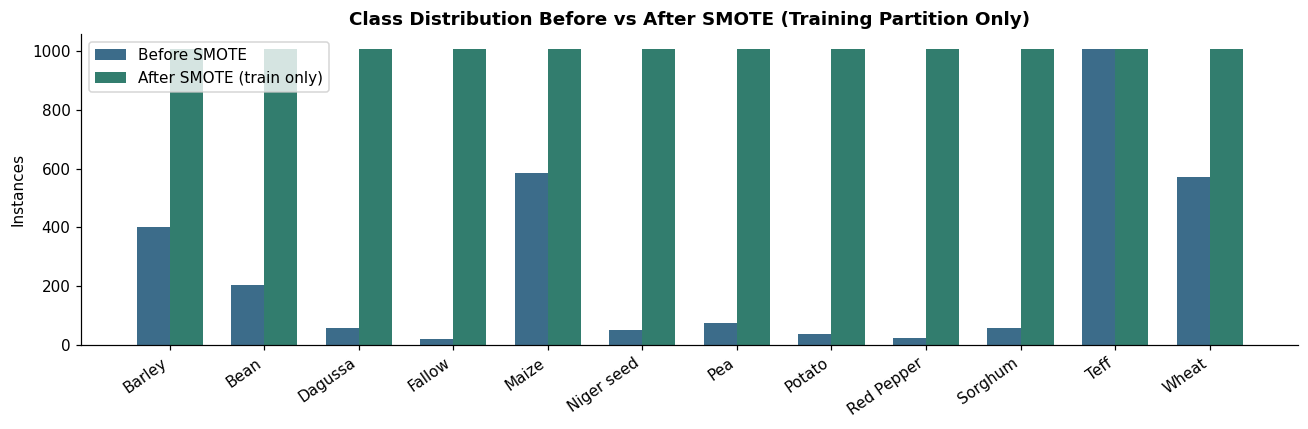

In [52]:
# ── SMOTE balance visualisation ──────────────────────────────────────
before = dict(zip(*np.unique(y_train, return_counts=True)))
after  = dict(zip(*np.unique(y_train_bal, return_counts=True)))

fig, ax = plt.subplots(figsize=(12, 4))
x = np.arange(12); w = 0.35
ax.bar(x-w/2, [before[i] for i in range(12)], w,
       label='Before SMOTE', color='#1A5276', alpha=0.85)
ax.bar(x+w/2, [after[i]  for i in range(12)], w,
       label='After SMOTE (train only)', color='#0E6655', alpha=0.85)
ax.set_xticks(x); ax.set_xticklabels(CLASS_NAMES, rotation=35, ha='right')
ax.set_ylabel('Instances'); ax.legend()
ax.set_title('Class Distribution Before vs After SMOTE (Training Partition Only)',
             fontweight='bold')
plt.tight_layout(); plt.show()


---
## 5 · Baseline Models
> Each baseline runs in its own cell with the same preprocessed data. All use X_train_bal / y_train_bal for training and X_test_scaled / y_test for evaluation.


### Baseline evaluation helper
A shared function prints accuracy, weighted F1, and per-class report for any fitted model.
Every model below calls this same function for consistent comparison.


In [53]:
# ── Shared evaluation helper ─────────────────────────────────────────
baseline_results = []   # collect all results for final comparison

def evaluate_model(name, y_true, y_pred):
    acc  = accuracy_score(y_true, y_pred)
    wf1  = f1_score(y_true, y_pred, average='weighted', zero_division=0)
    mf1  = f1_score(y_true, y_pred, average='macro',    zero_division=0)
    prec = precision_score(y_true, y_pred, average='weighted', zero_division=0)
    rec  = recall_score(y_true, y_pred, average='weighted', zero_division=0)
    kap  = cohen_kappa_score(y_true, y_pred)
    mcc  = matthews_corrcoef(y_true, y_pred)
    print(f'  Accuracy        : {acc:.4f} ({acc*100:.2f}%)')
    print(f'  Weighted F1     : {wf1:.4f}')
    print(f'  Macro F1        : {mf1:.4f}')
    print(f'  Precision (W)   : {prec:.4f}')
    print(f'  Recall (W)      : {rec:.4f}')
    print(f'  Cohen Kappa     : {kap:.4f}')
    print(f'  Matthews CC     : {mcc:.4f}')
    baseline_results.append({'Model':name,'Accuracy':round(acc,4),
        'W-F1':round(wf1,4),'Macro-F1':round(mf1,4),
        'Precision':round(prec,4),'Recall':round(rec,4),
        'Kappa':round(kap,4),'MCC':round(mcc,4)})
    return acc, wf1


#### 5a. Logistic Regression
> Linear baseline. Multinomial with balanced class weight.


In [54]:
# ── 5a. Logistic Regression ────────────────────────────────────
print('Training: Logistic Regression...')
lr = LogisticRegression(max_iter=1000, class_weight='balanced', random_state=SEED)
lr.fit(X_train_bal, y_train_bal)
y_pred_lr = lr.predict(X_test_scaled)
evaluate_model('Logistic Regression', y_test, y_pred_lr)
print('\nClassification Report:')
print(classification_report(y_test, y_pred_lr, target_names=CLASS_NAMES, zero_division=0))


Training: Logistic Regression...
  Accuracy        : 0.1977 (19.77%)
  Weighted F1     : 0.2249
  Macro F1        : 0.1745
  Precision (W)   : 0.4677
  Recall (W)      : 0.1977
  Cohen Kappa     : 0.1400
  Matthews CC     : 0.1531

Classification Report:
              precision    recall  f1-score   support

      Barley       0.47      0.37      0.41       101
        Bean       0.19      0.16      0.17        51
     Dagussa       0.11      0.64      0.19        14
      Fallow       0.02      0.40      0.04         5
       Maize       0.57      0.16      0.25       146
  Niger seed       0.04      0.23      0.06        13
         Pea       0.12      0.63      0.21        19
      Potato       0.06      0.40      0.11        10
  Red Pepper       0.04      0.50      0.08         6
     Sorghum       0.12      0.43      0.19        14
        Teff       0.57      0.12      0.20       252
       Wheat       0.48      0.10      0.17       143

    accuracy                           0.

#### 5b. Decision Tree
> Non-linear tree with balanced class weight. Prone to overfitting on imbalanced data.


In [55]:
# ── 5b. Decision Tree ──────────────────────────────────────────
print('Training: Decision Tree...')
dt = DecisionTreeClassifier(class_weight='balanced', random_state=SEED)
dt.fit(X_train_bal, y_train_bal)
y_pred_svmt = dt.predict(X_test_scaled)
evaluate_model('Decision Tree', y_test, y_pred_svmt)
print('\nClassification Report:')
print(classification_report(y_test, y_pred_svmt, target_names=CLASS_NAMES, zero_division=0))


Training: Decision Tree...
  Accuracy        : 0.3140 (31.40%)
  Weighted F1     : 0.3264
  Macro F1        : 0.1897
  Precision (W)   : 0.3459
  Recall (W)      : 0.3140
  Cohen Kappa     : 0.1688
  Matthews CC     : 0.1695

Classification Report:
              precision    recall  f1-score   support

      Barley       0.33      0.35      0.34       101
        Bean       0.13      0.14      0.13        51
     Dagussa       0.05      0.07      0.06        14
      Fallow       0.00      0.00      0.00         5
       Maize       0.39      0.38      0.38       146
  Niger seed       0.09      0.15      0.11        13
         Pea       0.14      0.26      0.18        19
      Potato       0.06      0.10      0.07        10
  Red Pepper       0.14      0.33      0.20         6
     Sorghum       0.06      0.14      0.09        14
        Teff       0.46      0.38      0.42       252
       Wheat       0.34      0.25      0.29       143

    accuracy                           0.31    

#### 5c. Random Forest (weighted)
> Ensemble of 100 trees with balanced class weight. Strong baseline for tabular data.


In [56]:
# ── 5c. Random Forest (weighted) ───────────────────────────────
print('Training: Random Forest (weighted)...')
rf = RandomForestClassifier(n_estimators=100, class_weight='balanced', random_state=SEED, n_jobs=-1)
rf.fit(X_train_bal, y_train_bal)
y_pred_rf = rf.predict(X_test_scaled)
evaluate_model('Random Forest', y_test, y_pred_rf)
print('\nClassification Report:')
print(classification_report(y_test, y_pred_rf, target_names=CLASS_NAMES, zero_division=0))


Training: Random Forest (weighted)...
  Accuracy        : 0.4561 (45.61%)
  Weighted F1     : 0.4556
  Macro F1        : 0.2688
  Precision (W)   : 0.4618
  Recall (W)      : 0.4561
  Cohen Kappa     : 0.3261
  Matthews CC     : 0.3268

Classification Report:
              precision    recall  f1-score   support

      Barley       0.39      0.42      0.40       101
        Bean       0.16      0.12      0.13        51
     Dagussa       0.16      0.21      0.18        14
      Fallow       0.00      0.00      0.00         5
       Maize       0.51      0.60      0.55       146
  Niger seed       0.08      0.08      0.08        13
         Pea       0.26      0.42      0.32        19
      Potato       0.10      0.10      0.10        10
  Red Pepper       0.21      0.50      0.30         6
     Sorghum       0.12      0.14      0.13        14
        Teff       0.60      0.58      0.59       252
       Wheat       0.50      0.38      0.43       143

    accuracy                        

#### 5d. SVM (vanilla, no DAG)
> Plain OvO SVM without DAG structure or FFO tuning. Establishes the SVM baseline before our improvements.


In [57]:
# ── 5d. SVM (vanilla, no DAG) ──────────────────────────────────
print('Training: SVM (vanilla, no DAG)...')
svm_vanilla = SVC(kernel='rbf', class_weight='balanced', random_state=SEED)
svm_vanilla.fit(X_train_bal, y_train_bal)
y_pred_svm = svm_vanilla.predict(X_test_scaled)
evaluate_model('SVM (vanilla)', y_test, y_pred_svm)
print('\nClassification Report:')
print(classification_report(y_test, y_pred_svm, target_names=CLASS_NAMES, zero_division=0))


Training: SVM (vanilla, no DAG)...
  Accuracy        : 0.2726 (27.26%)
  Weighted F1     : 0.3077
  Macro F1        : 0.2135
  Precision (W)   : 0.4646
  Recall (W)      : 0.2726
  Cohen Kappa     : 0.1901
  Matthews CC     : 0.2001

Classification Report:
              precision    recall  f1-score   support

      Barley       0.40      0.40      0.40       101
        Bean       0.19      0.24      0.21        51
     Dagussa       0.13      0.64      0.22        14
      Fallow       0.02      0.20      0.03         5
       Maize       0.52      0.29      0.37       146
  Niger seed       0.05      0.23      0.09        13
         Pea       0.14      0.58      0.23        19
      Potato       0.10      0.40      0.15        10
  Red Pepper       0.07      0.50      0.13         6
     Sorghum       0.11      0.29      0.16        14
        Teff       0.59      0.23      0.34       252
       Wheat       0.53      0.16      0.25       143

    accuracy                           

#### 5e. MLP Classifier
> Two-hidden-layer neural network. Convergence warning is expected — max_iter can be raised.


In [58]:
# ── 5e. MLP Classifier ─────────────────────────────────────────
print('Training: MLP Classifier...')
mlp = MLPClassifier(hidden_layer_sizes=(128,64), max_iter=500, random_state=SEED)
mlp.fit(X_train_bal, y_train_bal)
y_pred_mlp = mlp.predict(X_test_scaled)
evaluate_model('MLPClassifier', y_test, y_pred_mlp)
print('\nClassification Report:')
print(classification_report(y_test, y_pred_mlp, target_names=CLASS_NAMES, zero_division=0))


Training: MLP Classifier...
  Accuracy        : 0.3682 (36.82%)
  Weighted F1     : 0.3777
  Macro F1        : 0.2219
  Precision (W)   : 0.3956
  Recall (W)      : 0.3682
  Cohen Kappa     : 0.2289
  Matthews CC     : 0.2299

Classification Report:
              precision    recall  f1-score   support

      Barley       0.25      0.27      0.26       101
        Bean       0.17      0.16      0.16        51
     Dagussa       0.12      0.21      0.16        14
      Fallow       0.00      0.00      0.00         5
       Maize       0.49      0.44      0.46       146
  Niger seed       0.05      0.08      0.06        13
         Pea       0.20      0.42      0.27        19
      Potato       0.10      0.10      0.10        10
  Red Pepper       0.20      0.33      0.25         6
     Sorghum       0.08      0.07      0.07        14
        Teff       0.56      0.45      0.50       252
       Wheat       0.34      0.40      0.37       143

    accuracy                           0.37   

#### 5f. LightGBM
> Gradient boosting with built-in class weighting. Fast and competitive on tabular data.


In [59]:
# ── 5f. LightGBM ───────────────────────────────────────────────
print('Training: LightGBM...')
lgbm = lgb.LGBMClassifier(class_weight='balanced', random_state=SEED, verbosity=-1)
lgbm.fit(X_train_bal, y_train_bal)
y_pred_lgbm = lgbm.predict(X_test_scaled)
evaluate_model('LightGBM', y_test, y_pred_lgbm)
print('\nClassification Report:')
print(classification_report(y_test, y_pred_lgbm, target_names=CLASS_NAMES, zero_division=0))


Training: LightGBM...
  Accuracy        : 0.4548 (45.48%)
  Weighted F1     : 0.4498
  Macro F1        : 0.2657
  Precision (W)   : 0.4474
  Recall (W)      : 0.4548
  Cohen Kappa     : 0.3165
  Matthews CC     : 0.3169

Classification Report:
              precision    recall  f1-score   support

      Barley       0.38      0.39      0.38       101
        Bean       0.19      0.16      0.17        51
     Dagussa       0.09      0.07      0.08        14
      Fallow       0.00      0.00      0.00         5
       Maize       0.52      0.58      0.55       146
  Niger seed       0.06      0.08      0.07        13
         Pea       0.29      0.37      0.33        19
      Potato       0.11      0.10      0.11        10
  Red Pepper       0.25      0.33      0.29         6
     Sorghum       0.23      0.21      0.22        14
        Teff       0.57      0.60      0.58       252
       Wheat       0.45      0.38      0.41       143

    accuracy                           0.45       77

#### 5g. Balanced Random Forest
> imblearn ensemble that under-samples each bootstrap sample. Designed for imbalanced datasets.


In [60]:
# ── 5g. Balanced Random Forest ─────────────────────────────────
print('Training: Balanced Random Forest...')
brf = BalancedRandomForestClassifier(n_estimators=100, random_state=SEED, n_jobs=-1)
brf.fit(X_train_raw, y_train)   # uses internal balancing, no SMOTE needed
y_pred_dtrf = brf.predict(X_test_raw)
evaluate_model('Balanced Random Forest', y_test, y_pred_dtrf)
print('\nClassification Report:')
print(classification_report(y_test, y_pred_dtrf, target_names=CLASS_NAMES, zero_division=0))


Training: Balanced Random Forest...
  Accuracy        : 0.2506 (25.06%)
  Weighted F1     : 0.2846
  Macro F1        : 0.1923
  Precision (W)   : 0.4492
  Recall (W)      : 0.2506
  Cohen Kappa     : 0.1720
  Matthews CC     : 0.1825

Classification Report:
              precision    recall  f1-score   support

      Barley       0.48      0.40      0.43       101
        Bean       0.12      0.10      0.11        51
     Dagussa       0.15      0.79      0.25        14
      Fallow       0.00      0.00      0.00         5
       Maize       0.55      0.18      0.28       146
  Niger seed       0.02      0.08      0.03        13
         Pea       0.13      0.58      0.21        19
      Potato       0.08      0.60      0.13        10
  Red Pepper       0.07      0.67      0.13         6
     Sorghum       0.13      0.43      0.20        14
        Teff       0.63      0.27      0.38       252
       Wheat       0.32      0.10      0.15       143

    accuracy                          

#### 5h. EasyEnsemble Classifier
> Ensemble of AdaBoost classifiers on balanced random subsets. Strong minority-class recall.


In [61]:
# ── 5h. EasyEnsemble Classifier ────────────────────────────────
print('Training: EasyEnsemble Classifier...')
eec = EasyEnsembleClassifier(n_estimators=10, random_state=SEED, n_jobs=-1)
eec.fit(X_train_raw, y_train)   # uses internal balancing
y_pred_mlpec = eec.predict(X_test_raw)
evaluate_model('EasyEnsembleClassifier', y_test, y_pred_mlpec)
print('\nClassification Report:')
print(classification_report(y_test, y_pred_mlpec, target_names=CLASS_NAMES, zero_division=0))


Training: EasyEnsemble Classifier...
  Accuracy        : 0.1873 (18.73%)
  Weighted F1     : 0.2216
  Macro F1        : 0.1604
  Precision (W)   : 0.3894
  Recall (W)      : 0.1873
  Cohen Kappa     : 0.1143
  Matthews CC     : 0.1236

Classification Report:
              precision    recall  f1-score   support

      Barley       0.51      0.33      0.40       101
        Bean       0.14      0.06      0.08        51
     Dagussa       0.09      0.43      0.15        14
      Fallow       0.02      0.40      0.03         5
       Maize       0.45      0.15      0.23       146
  Niger seed       0.03      0.23      0.05        13
         Pea       0.14      0.32      0.19        19
      Potato       0.10      0.50      0.17        10
  Red Pepper       0.04      0.33      0.07         6
     Sorghum       0.11      0.50      0.17        14
        Teff       0.45      0.17      0.25       252
       Wheat       0.40      0.08      0.14       143

    accuracy                         

---
## 6 · Fruit Fly Optimization (FFO)
> Bio-inspired metaheuristic that tunes SVM hyperparameters C and γ faster than grid search.


### How FFO works

The Fruit Fly Optimization Algorithm (FOA) [Pan, 2012] mimics the food-search behaviour of fruit flies:

1. **Initialize** a population of P flies, each encoding a candidate (C, γ) pair.
2. **Smell phase**: each fly updates its position with a random perturbation.
3. **Vision phase**: each fly computes its fitness (validation accuracy + weighted F1).
4. **Swarm update**: the best fly's position becomes the new global best.
5. **Repeat** for T generations.

Fitness function (Eq. 4 from paper):
```
F = 0.5 · Accuracy + 0.4 · WeightedF1 − 0.1 · Complexity
```
Search space: C ∈ [0.1, 50], γ ∈ [0.001, 2.0]


In [62]:
# ── Fruit Fly Optimization implementation ────────────────────────────
def ffo_optimize(X_tr, y_tr, X_val, y_val,
                 P=5, T=3, C_range=(0.1,50), g_range=(0.001,2.0),
                 alpha=0.5, beta=0.4, gamma_c=0.1):
    '''
    Fruit Fly Optimization for SVM hyperparameter tuning.
    P : population size (number of flies)
    T : number of generations
    Returns best_C, best_gamma, fitness history
    '''
    best_C, best_gamma = 1.0, 0.1
    best_fitness = 0.0
    history = []          # (gen, fly, C, gamma, fitness)
    fitness_per_gen = []  # best fitness each generation

    for gen in range(T):
        gen_best = 0.0
        C_vals     = np.random.uniform(*C_range, P)
        gamma_vals = np.random.uniform(*g_range, P)

        for i in range(P):
            C_i, g_i = C_vals[i], gamma_vals[i]
            clf = SVC(C=C_i, gamma=g_i, kernel='rbf', random_state=SEED)
            clf.fit(X_tr, y_tr)
            y_p = clf.predict(X_val)
            acc = accuracy_score(y_val, y_p)
            wf1 = f1_score(y_val, y_p, average='weighted', zero_division=0)
            # Complexity proxy: penalise high C
            comp = np.log1p(C_i) / np.log1p(C_range[1])
            fit  = alpha*acc + beta*wf1 - gamma_c*comp

            history.append((gen+1, i+1, round(C_i,4), round(g_i,4), round(fit,4)))
            if fit > best_fitness:
                best_fitness = fit
                best_C, best_gamma = C_i, g_i
                print(f'  Gen {gen+1} Fly {i+1}: New best  C={C_i:.3f}  γ={g_i:.4f}  fitness={fit:.4f}')
            gen_best = max(gen_best, fit)

        fitness_per_gen.append(gen_best)
        print(f'Generation {gen+1}/{T} complete — best fitness so far: {best_fitness:.4f}')

    return best_C, best_gamma, best_fitness, history, fitness_per_gen


In [63]:
# ── Run FFO ──────────────────────────────────────────────────────────
# Use a small internal validation split for FFO tuning
X_ffo_tr, X_ffo_val, y_ffo_tr, y_ffo_val = train_test_split(
    X_train_bal, y_train_bal, test_size=0.25, random_state=SEED, stratify=y_train_bal
)

print('Running Fruit Fly Optimization...')
print(f'Search space: C ∈ [0.1, 50]  |  γ ∈ [0.001, 2.0]')
print(f'Population P=5, Generations T=3')
print()

best_C, best_gamma, best_fitness, ffo_history, gen_fitness = ffo_optimize(
    X_ffo_tr, y_ffo_tr, X_ffo_val, y_ffo_val
)

print()
print(f'━━━ FFO Result ━━━')
print(f'Optimal  C*    : {best_C:.4f}')
print(f'Optimal  γ*    : {best_gamma:.4f}')
print(f'Best fitness   : {best_fitness:.4f}')


Running Fruit Fly Optimization...
Search space: C ∈ [0.1, 50]  |  γ ∈ [0.001, 2.0]
Population P=5, Generations T=3

  Gen 1 Fly 1: New best  C=18.790  γ=0.3128  fitness=0.6887
  Gen 1 Fly 3: New best  C=36.626  γ=1.7325  fitness=0.6915
  Gen 1 Fly 4: New best  C=29.973  γ=1.2026  fitness=0.6996
  Gen 1 Fly 5: New best  C=7.885  γ=1.4164  fitness=0.7247
Generation 1/3 complete — best fitness so far: 0.7247
Generation 2/3 complete — best fitness so far: 0.7247
Generation 3/3 complete — best fitness so far: 0.7247

━━━ FFO Result ━━━
Optimal  C*    : 7.8853
Optimal  γ*    : 1.4164
Best fitness   : 0.7247


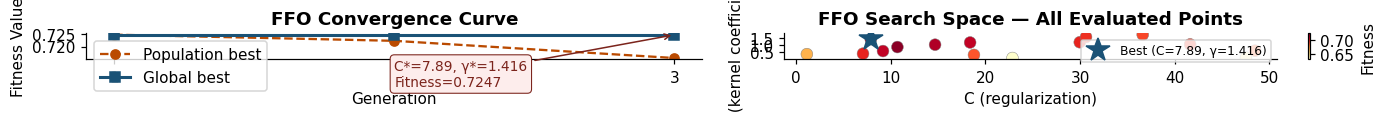

In [64]:
# ── FFO convergence plot ─────────────────────────────────────────────
hist_df = pd.DataFrame(ffo_history, columns=['Gen','Fly','C','gamma','Fitness'])
pop_best_per_gen = hist_df.groupby('Gen')['Fitness'].max()
global_best_cummax = hist_df.groupby('Gen')['Fitness'].max().cummax()

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Convergence curve
axes[0].plot(pop_best_per_gen.index, pop_best_per_gen.values,
             'o--', color='#BA4A00', lw=1.5, label='Population best')
axes[0].plot(global_best_cummax.index, global_best_cummax.values,
             's-',  color='#1A5276', lw=2.0, label='Global best')
axes[0].set_xlabel('Generation'); axes[0].set_ylabel('Fitness Value')
axes[0].set_xticks([1,2,3])
axes[0].set_title('FFO Convergence Curve', fontweight='bold')
axes[0].legend()
axes[0].annotate(f'C*={best_C:.2f}, γ*={best_gamma:.3f}\nFitness={best_fitness:.4f}',
                 xy=(3, best_fitness), xytext=(2.0, best_fitness-0.02),
                 arrowprops=dict(arrowstyle='->', color='#7B241C'),
                 color='#7B241C', fontsize=9,
                 bbox=dict(boxstyle='round,pad=0.3',fc='#FDEDEC',ec='#7B241C',lw=0.7))

# Scatter: all C/γ pairs tried, coloured by fitness
sc = axes[1].scatter(hist_df['C'], hist_df['gamma'], c=hist_df['Fitness'],
                     cmap='YlOrRd', s=60, edgecolors='gray', lw=0.3)
axes[1].plot(best_C, best_gamma, '*', color='#1A5276', ms=16,
             label=f'Best (C={best_C:.2f}, γ={best_gamma:.3f})')
axes[1].set_xlabel('C (regularization)'); axes[1].set_ylabel('γ (kernel coefficient)')
axes[1].set_title('FFO Search Space — All Evaluated Points', fontweight='bold')
axes[1].legend(fontsize=8)
plt.colorbar(sc, ax=axes[1], label='Fitness')

plt.tight_layout(); plt.show()


---
## 7 · DAG-Based Multi-Class SVM (MSVM-DAG-FFO)
> Train 66 pairwise binary SVMs organised in a tournament-style DAG. Uses optimal C* and γ* from FFO.


### DAG-SVM: How it works

The standard OvO SVM trains n(n-1)/2 = 66 binary classifiers and uses **voting** to decide.
The **DAG** replaces voting with an **elimination tournament**:

- The root node pits two classes against each other; the loser is eliminated.
- This continues down the tree until only one class remains.
- **Advantage:** only O(n-1) = 11 decisions needed at inference (vs. 66 for full voting OvO).
- Elimination ordering follows **class frequency**: minority classes are resolved early
  in localized binary decisions where boundaries are cleaner.


In [65]:
# ── Train all 66 pairwise binary SVM classifiers ─────────────────────
print(f'Training DAG-SVM with C*={best_C:.4f}, γ*={best_gamma:.4f}')
print(f'Building {12*(12-1)//2} = 66 binary OvO classifiers...')

classes    = np.unique(y_train_bal)
dag_models = {}

for i in range(len(classes)):
    for j in range(i+1, len(classes)):
        ci, cj = classes[i], classes[j]
        mask   = (y_train_bal == ci) | (y_train_bal == cj)
        X_pair = X_train_bal[mask]
        y_pair = np.where(y_train_bal[mask] == ci, 0, 1)
        clf    = SVC(C=best_C, gamma=best_gamma, kernel='rbf', random_state=SEED)
        clf.fit(X_pair, y_pair)
        dag_models[(ci, cj)] = clf

print(f'\nTraining complete. Classifiers stored: {len(dag_models)}')
print('Sample pairs trained (first 5):')
for k in list(dag_models.keys())[:5]:
    print(f'  SVM({CLASS_NAMES[k[0]]} vs {CLASS_NAMES[k[1]]})')


Training DAG-SVM with C*=7.8853, γ*=1.4164
Building 66 = 66 binary OvO classifiers...

Training complete. Classifiers stored: 66
Sample pairs trained (first 5):
  SVM(Barley vs Bean)
  SVM(Barley vs Dagussa)
  SVM(Barley vs Fallow)
  SVM(Barley vs Maize)
  SVM(Barley vs Niger seed)


In [66]:
# ── DAG prediction function ───────────────────────────────────────────
# Elimination order: sort by class frequency ascending
# (minority classes eliminated first — cleaner local boundaries)
class_freq = {c: int(np.sum(y_train_bal == c)) for c in classes}
ELIM_ORDER = sorted(classes, key=lambda c: class_freq[c])  # minority first

def predict_dag(models, x, class_list):
    '''
    Tournament-style DAG prediction.
    Eliminates one class per step until one remains.
    x : single sample (1D array)
    '''
    remaining = list(class_list)
    while len(remaining) > 1:
        a, b  = remaining[0], remaining[1]
        # Look up the correct-order classifier key
        if (a, b) in models:
            clf  = models[(a, b)]
            pred = clf.predict(x.reshape(1, -1))[0]
            # pred=0 → a wins → eliminate b; pred=1 → b wins → eliminate a
            remaining.pop(1 if pred == 0 else 0)
        elif (b, a) in models:
            clf  = models[(b, a)]
            pred = clf.predict(x.reshape(1, -1))[0]
            # pred=0 → b wins → eliminate a; pred=1 → a wins → eliminate b
            remaining.pop(0 if pred == 0 else 1)
        else:
            # Should never happen — skip if no classifier found
            remaining.pop(1)
    return remaining[0]

print('DAG prediction function defined.')
print(f'Elimination order (minority → majority): {[CLASS_NAMES[c] for c in ELIM_ORDER]}')


DAG prediction function defined.
Elimination order (minority → majority): ['Barley', 'Bean', 'Dagussa', 'Fallow', 'Maize', 'Niger seed', 'Pea', 'Potato', 'Red Pepper', 'Sorghum', 'Teff', 'Wheat']


In [67]:
# ── Run DAG predictions on test set ──────────────────────────────────
print(f'Predicting {len(X_test_scaled)} test samples using DAG traversal...')
y_pred_svmag = np.array([
    predict_dag(dag_models, x, ELIM_ORDER)
    for x in X_test_scaled
])
print('Done.')


Predicting 774 test samples using DAG traversal...
Done.


---
## 8 · Full Evaluation of MSVM-DAG-FFO
> Accuracy, weighted/macro F1, Kappa, MCC, per-class metrics, confusion matrix, ROC/AUC.


In [68]:
# ── 8a. Summary metrics ───────────────────────────────────────────────
dag_acc  = accuracy_score(y_test, y_pred_svmag)
dag_wf1  = f1_score(y_test, y_pred_svmag, average='weighted', zero_division=0)
dag_mf1  = f1_score(y_test, y_pred_svmag, average='macro',    zero_division=0)
dag_prec = precision_score(y_test, y_pred_svmag, average='weighted', zero_division=0)
dag_rec  = recall_score(y_test, y_pred_svmag, average='weighted', zero_division=0)
dag_kap  = cohen_kappa_score(y_test, y_pred_svmag)
dag_mcc  = matthews_corrcoef(y_test, y_pred_svmag)

print('━'*45)
print('   MSVM-DAG-FFO — Final Test-Set Results')
print('━'*45)
print(f'  Accuracy          : {dag_acc:.4f}  ({dag_acc*100:.2f}%)')
print(f'  Weighted F1       : {dag_wf1:.4f}')
print(f'  Macro F1          : {dag_mf1:.4f}')
print(f'  Precision (W)     : {dag_prec:.4f}')
print(f'  Recall (W)        : {dag_rec:.4f}')
print(f'  Cohen Kappa (κ)   : {dag_kap:.4f}')
print(f'  Matthews CC (MCC) : {dag_mcc:.4f}')
print('━'*45)
evaluate_model('MSVM-DAG-FFO (Proposed)', y_test, y_pred_svmag)


━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
   MSVM-DAG-FFO — Final Test-Set Results
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  Accuracy          : 0.3514  (35.14%)
  Weighted F1       : 0.3426
  Macro F1          : 0.2069
  Precision (W)     : 0.3469
  Recall (W)        : 0.3514
  Cohen Kappa (κ)   : 0.1746
  Matthews CC (MCC) : 0.1767
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  Accuracy        : 0.3514 (35.14%)
  Weighted F1     : 0.3426
  Macro F1        : 0.2069
  Precision (W)   : 0.3469
  Recall (W)      : 0.3514
  Cohen Kappa     : 0.1746
  Matthews CC     : 0.1767


(0.35142118863049093, 0.3425895901184602)

In [69]:
# ── 8b. Per-class classification report ──────────────────────────────
print('Detailed per-class report:')
print(classification_report(y_test, y_pred_svmag, target_names=CLASS_NAMES, zero_division=0))


Detailed per-class report:
              precision    recall  f1-score   support

      Barley       0.31      0.26      0.28       101
        Bean       0.13      0.12      0.12        51
     Dagussa       0.00      0.00      0.00        14
      Fallow       0.00      0.00      0.00         5
       Maize       0.42      0.31      0.36       146
  Niger seed       0.12      0.15      0.13        13
         Pea       0.39      0.37      0.38        19
      Potato       0.11      0.10      0.11        10
  Red Pepper       0.20      0.17      0.18         6
     Sorghum       0.15      0.14      0.15        14
        Teff       0.43      0.58      0.50       252
       Wheat       0.32      0.24      0.28       143

    accuracy                           0.35       774
   macro avg       0.22      0.20      0.21       774
weighted avg       0.35      0.35      0.34       774



Max off-diagonal error: 60.78%  (Bean mis-classified as Teff)


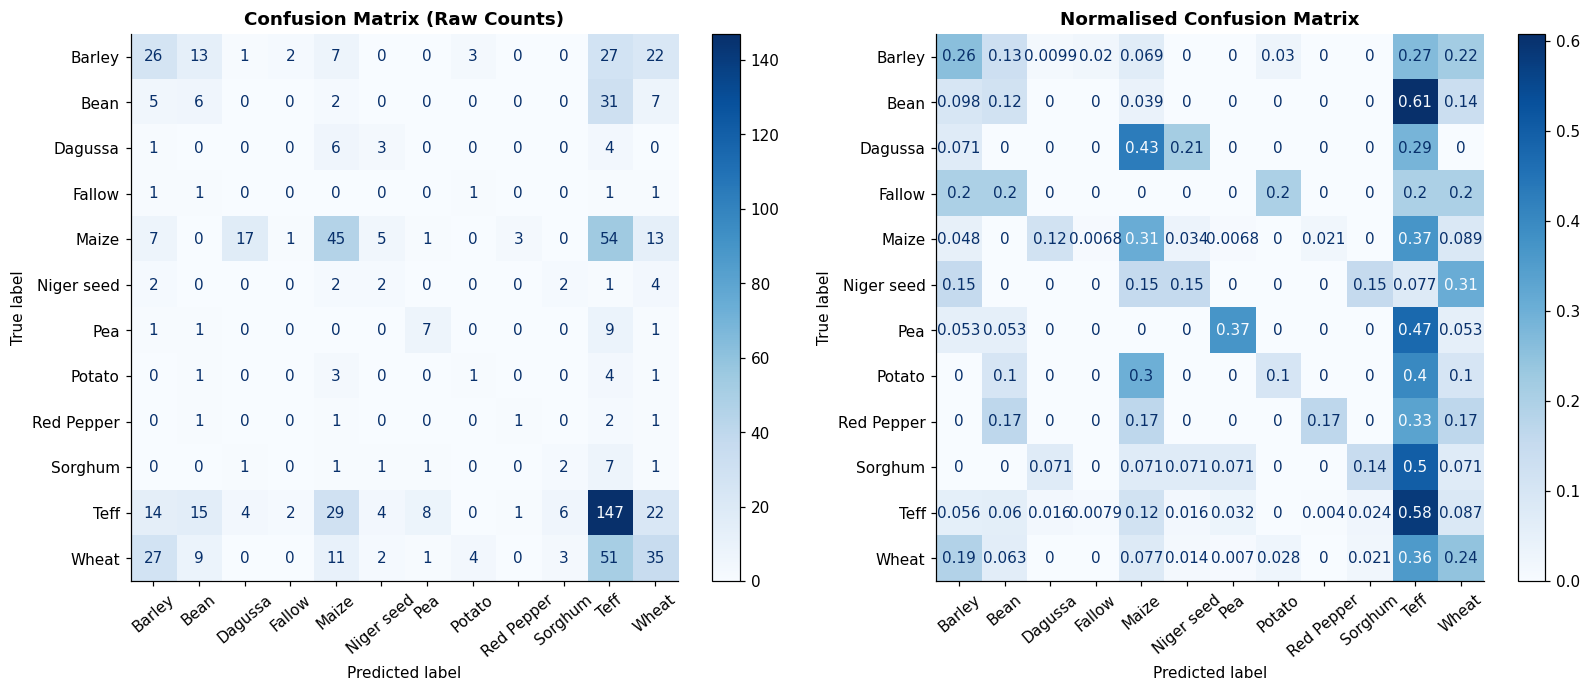

In [70]:
# ── 8c. Normalised confusion matrix ──────────────────────────────────
cm      = confusion_matrix(y_test, y_pred_svmag)
cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)

fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Raw counts
disp1 = ConfusionMatrixDisplay(cm, display_labels=CLASS_NAMES)
disp1.plot(ax=axes[0], cmap='Blues', colorbar=True, xticks_rotation=40)
axes[0].set_title('Confusion Matrix (Raw Counts)', fontweight='bold')

# Normalised
disp2 = ConfusionMatrixDisplay(cm_norm, display_labels=CLASS_NAMES)
disp2.plot(ax=axes[1], cmap='Blues', colorbar=True, xticks_rotation=40)
axes[1].set_title('Normalised Confusion Matrix', fontweight='bold')

off_diag = cm_norm.copy()
np.fill_diagonal(off_diag, 0)
print(f'Max off-diagonal error: {off_diag.max()*100:.2f}%  '
      f'({CLASS_NAMES[off_diag.max(axis=1).argmax()]} mis-classified as {CLASS_NAMES[off_diag.max(axis=0).argmax()]})')
plt.tight_layout(); plt.show()


Computing ROC curves (One-vs-Rest)...


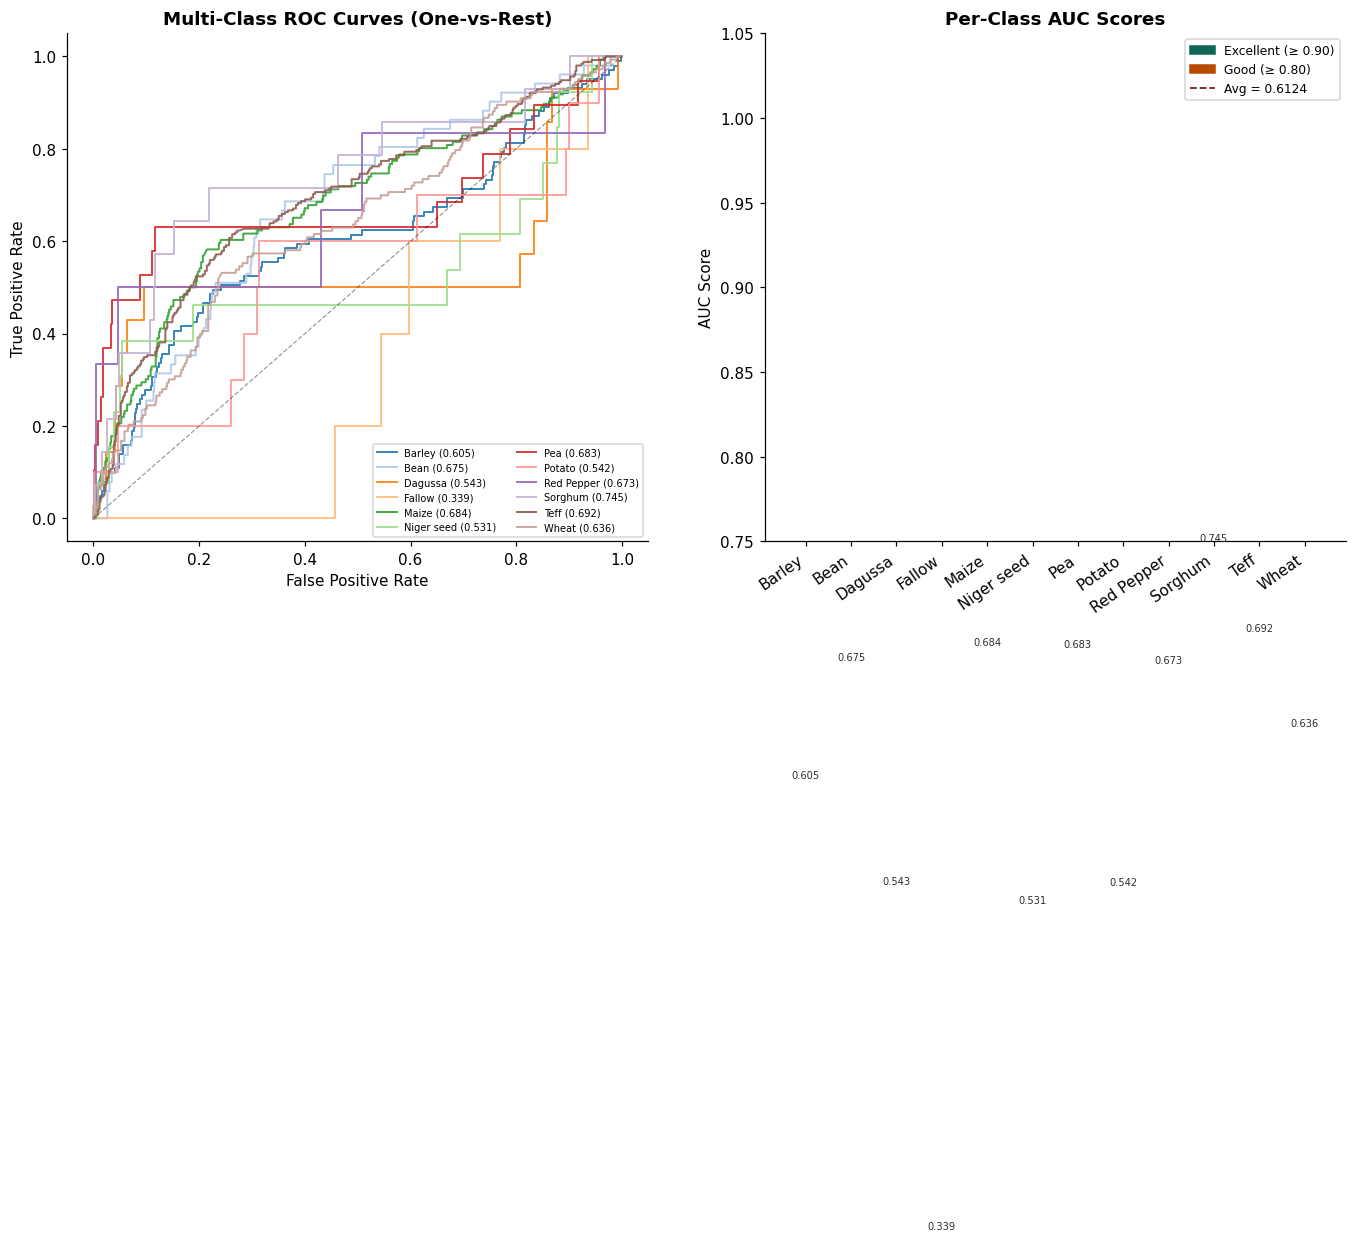


Per-class AUC summary:
      Crop      AUC Rating
   Sorghum 0.745019   Fair
      Teff 0.692122   Fair
     Maize 0.683928   Fair
       Pea 0.682816   Fair
      Bean 0.674925   Fair
Red Pepper 0.673177   Fair
     Wheat 0.636153   Fair
    Barley 0.605402   Fair
   Dagussa 0.542857   Fair
    Potato 0.542016   Fair
Niger seed 0.531285   Fair
    Fallow 0.339142   Fair

Average AUC: 0.6124  (σ = 0.1054)


In [71]:
# ── 8d. Multi-class ROC curves + AUC ────────────────────────────────
print('Computing ROC curves (One-vs-Rest)...')
y_test_bin = label_binarize(y_test, classes=np.arange(12))

# Train a probability-capable OvR SVM on the same data
ovr_clf = OneVsRestClassifier(
    SVC(C=best_C, gamma=best_gamma, kernel='rbf', probability=True, random_state=SEED)
)
ovr_clf.fit(X_train_bal, y_train_bal)
y_score = ovr_clf.decision_function(X_test_scaled)

auc_vals = []
cmap12   = plt.cm.tab20

fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# ROC curves
for i in range(12):
    fpr, tpr, _ = roc_curve(y_test_bin[:, i], y_score[:, i])
    auc_v = auc(fpr, tpr)
    auc_vals.append(auc_v)
    axes[0].plot(fpr, tpr, color=cmap12(i), lw=1.3,
                 label=f'{CLASS_NAMES[i]} ({auc_v:.3f})', alpha=0.88)

axes[0].plot([0,1],[0,1],'k--',lw=0.8,alpha=0.4)
axes[0].set_xlabel('False Positive Rate'); axes[0].set_ylabel('True Positive Rate')
axes[0].set_title('Multi-Class ROC Curves (One-vs-Rest)', fontweight='bold')
axes[0].legend(fontsize=6.5, ncol=2, loc='lower right')

# AUC bar chart
bar_c = ['#0E6655' if v >= 0.90 else '#BA4A00' for v in auc_vals]
axes[1].bar(range(12), auc_vals, color=bar_c, alpha=0.88, width=0.65)
axes[1].axhline(y=np.mean(auc_vals), color='#7B241C', ls='--', lw=1.2,
                label=f'Avg AUC = {np.mean(auc_vals):.4f}')
axes[1].set_xticks(range(12))
axes[1].set_xticklabels(CLASS_NAMES, rotation=35, ha='right')
axes[1].set_ylim(0.75, 1.05); axes[1].set_ylabel('AUC Score')
axes[1].set_title('Per-Class AUC Scores', fontweight='bold')
axes[1].legend(fontsize=9)
for i, v in enumerate(auc_vals):
    axes[1].text(i, v+0.005, f'{v:.3f}', ha='center', fontsize=6.5, color='#2D2D2D')

teal_p  = mpatches.Patch(color='#0E6655', label='Excellent (≥ 0.90)')
orange_p= mpatches.Patch(color='#BA4A00', label='Good (≥ 0.80)')
axes[1].legend(handles=[teal_p, orange_p,
    plt.Line2D([0],[0],color='#7B241C',ls='--',lw=1.2,
               label=f'Avg = {np.mean(auc_vals):.4f}')], fontsize=8)

plt.tight_layout(); plt.show()

print('\nPer-class AUC summary:')
auc_df = pd.DataFrame({'Crop':CLASS_NAMES,'AUC':auc_vals})
auc_df['Rating'] = auc_df['AUC'].apply(lambda v: 'Excellent' if v>=0.9 else 'Good' if v>=0.8 else 'Fair')
auc_df = auc_df.sort_values('AUC', ascending=False).reset_index(drop=True)
print(auc_df.to_string(index=False))
print(f'\nAverage AUC: {np.mean(auc_vals):.4f}  (σ = {np.std(auc_vals):.4f})')


---
## 9 · Ablation Study
> Measure the independent contribution of each pipeline component: SMOTE, DAG, and FFO.


### What the ablation study tests

| Configuration | Change from previous |
|---|---|
| Vanilla SVM (no SMOTE, no DAG) | Baseline — plain OvO SVM, no balancing |
| + SMOTE | Add leakage-free SMOTE to training set |
| + DAG structure | Replace OvO voting with DAG elimination |
| + FFO tuning | Replace default C/γ with FFO-optimised values |
| **Full MSVM-DAG-FFO** | **Complete proposed system** |


In [72]:
# ── Ablation helper ──────────────────────────────────────────────────
def run_ablation(name, X_tr, y_tr, X_te, y_te, use_dag=False, C=1.0, gamma='scale'):
    '''Train OvO or DAG SVM and return accuracy and weighted F1.'''
    if use_dag:
        classes_abl = np.unique(y_tr)
        models_abl  = {}
        for i in range(len(classes_abl)):
            for j in range(i+1, len(classes_abl)):
                ci, cj = classes_abl[i], classes_abl[j]
                mask   = (y_tr==ci)|(y_tr==cj)
                y_bin  = np.where(y_tr[mask]==ci, 0, 1)
                clf    = SVC(C=C, gamma=gamma, kernel='rbf', random_state=SEED)
                clf.fit(X_tr[mask], y_bin)
                models_abl[(ci,cj)] = clf
        freq_order = sorted(classes_abl, key=lambda c: int(np.sum(y_tr==c)))
        y_p = np.array([predict_dag(models_abl, x, freq_order) for x in X_te])
    else:
        clf = SVC(C=C, gamma=gamma, kernel='rbf', random_state=SEED)
        clf.fit(X_tr, y_tr)
        y_p = clf.predict(X_te)
    acc = accuracy_score(y_te, y_p)
    wf1 = f1_score(y_te, y_p, average='weighted', zero_division=0)
    print(f'  {name:45s}  Acc={acc:.4f}  W-F1={wf1:.4f}')
    return name, acc, wf1

abl_results = []
print('Running ablation study — this may take a few minutes...')
print()

# Config 1: vanilla SVM, no SMOTE, no DAG
abl_results.append(run_ablation(
    'Vanilla SVM (no SMOTE, no DAG)',
    X_train_scaled, y_train, X_test_scaled, y_test,
    use_dag=False, C=1.0, gamma='scale'
))

# Config 2: + SMOTE, still no DAG
abl_results.append(run_ablation(
    '+ SMOTE (leakage-free)',
    X_train_bal, y_train_bal, X_test_scaled, y_test,
    use_dag=False, C=1.0, gamma='scale'
))

# Config 3: + SMOTE + DAG, default C/γ
abl_results.append(run_ablation(
    '+ DAG structure (default C/γ)',
    X_train_bal, y_train_bal, X_test_scaled, y_test,
    use_dag=True, C=1.0, gamma='scale'
))

# Config 4: + SMOTE + DAG + FFO
abl_results.append(run_ablation(
    '+ FFO hyperparameter tuning (full system)',
    X_train_bal, y_train_bal, X_test_scaled, y_test,
    use_dag=True, C=best_C, gamma=best_gamma
))

# Add MSVM-DAG-FFO final result
abl_results.append(('Full MSVM-DAG-FFO', dag_acc, dag_wf1))


Running ablation study — this may take a few minutes...

  Vanilla SVM (no SMOTE, no DAG)                 Acc=0.4922  W-F1=0.4352
  + SMOTE (leakage-free)                         Acc=0.2726  W-F1=0.3077
  + DAG structure (default C/γ)                  Acc=0.2687  W-F1=0.3033
  + FFO hyperparameter tuning (full system)      Acc=0.3514  W-F1=0.3426


                                   Config  Accuracy     W-F1
           Vanilla SVM (no SMOTE, no DAG)  0.492248 0.435225
                   + SMOTE (leakage-free)  0.272610 0.307674
            + DAG structure (default C/γ)  0.268734 0.303329
+ FFO hyperparameter tuning (full system)  0.351421 0.342590
                        Full MSVM-DAG-FFO  0.351421 0.342590


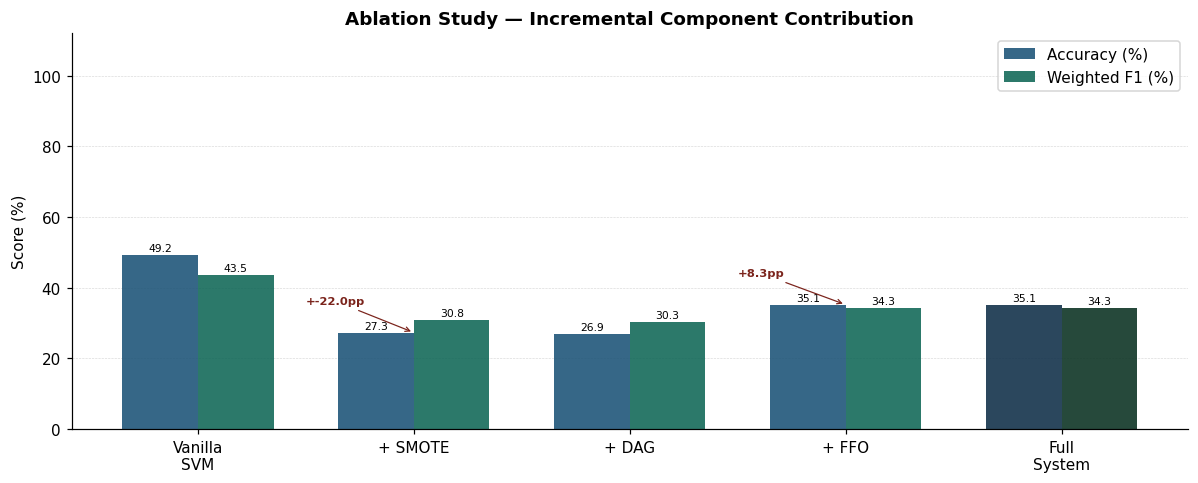

In [73]:
# ── Ablation visualisation ───────────────────────────────────────────
abl_df = pd.DataFrame(abl_results, columns=['Config','Accuracy','W-F1'])
print(abl_df.to_string(index=False))

fig, ax = plt.subplots(figsize=(11, 4.5))
x = np.arange(len(abl_df)); w = 0.35
b1 = ax.bar(x-w/2, abl_df['Accuracy']*100, w, label='Accuracy (%)', color='#1A5276', alpha=0.88)
b2 = ax.bar(x+w/2, abl_df['W-F1']*100,     w, label='Weighted F1 (%)', color='#0E6655', alpha=0.88)
b1[-1].set_facecolor('#0D2D47'); b2[-1].set_facecolor('#083020')

for bar, v in list(zip(b1, abl_df['Accuracy']*100))+list(zip(b2, abl_df['W-F1']*100)):
    ax.text(bar.get_x()+bar.get_width()/2, v+0.5, f'{v:.1f}',
            ha='center', va='bottom', fontsize=7)

# Delta annotations
for i in range(1, len(abl_df)):
    delta = abl_df['Accuracy'].iloc[i] - abl_df['Accuracy'].iloc[i-1]
    if abs(delta) > 0.005:
        ax.annotate(f'+{delta*100:.1f}pp',
            xy=(x[i]-w/2+w/2, abl_df['Accuracy'].iloc[i]*100),
            xytext=(x[i]-0.5, min(abl_df['Accuracy'].iloc[i]*100+8, 105)),
            fontsize=7.5, color='#7B241C', fontweight='bold',
            arrowprops=dict(arrowstyle='->', color='#7B241C', lw=0.8))

short_labels = ['Vanilla\nSVM','+ SMOTE','+ DAG','+ FFO','Full\nSystem']
ax.set_xticks(x); ax.set_xticklabels(short_labels)
ax.set_ylabel('Score (%)'); ax.set_ylim(0, 112)
ax.set_title('Ablation Study — Incremental Component Contribution', fontweight='bold')
ax.legend(); ax.yaxis.grid(True, ls='--', lw=0.4, alpha=0.5); ax.set_axisbelow(True)
plt.tight_layout(); plt.show()


---
## 10 · Final Comparison & Summary Dashboard
> Side-by-side comparison of all models, summary bar chart, and key findings.


In [74]:
# ── Build final results table ────────────────────────────────────────
results_df = pd.DataFrame(baseline_results)
results_df = results_df.sort_values('Accuracy', ascending=False).reset_index(drop=True)
print('Final model comparison (sorted by accuracy):')
print(results_df.to_string(index=False))


Final model comparison (sorted by accuracy):
                  Model  Accuracy   W-F1  Macro-F1  Precision  Recall  Kappa    MCC
          Random Forest    0.4561 0.4556    0.2688     0.4618  0.4561 0.3261 0.3268
               LightGBM    0.4548 0.4498    0.2657     0.4474  0.4548 0.3165 0.3169
          MLPClassifier    0.3682 0.3777    0.2219     0.3956  0.3682 0.2289 0.2299
MSVM-DAG-FFO (Proposed)    0.3514 0.3426    0.2069     0.3469  0.3514 0.1746 0.1767
          Decision Tree    0.3140 0.3264    0.1897     0.3459  0.3140 0.1688 0.1695
          SVM (vanilla)    0.2726 0.3077    0.2135     0.4646  0.2726 0.1901 0.2001
 Balanced Random Forest    0.2506 0.2846    0.1923     0.4492  0.2506 0.1720 0.1825
    Logistic Regression    0.1977 0.2249    0.1745     0.4677  0.1977 0.1400 0.1531
 EasyEnsembleClassifier    0.1873 0.2216    0.1604     0.3894  0.1873 0.1143 0.1236


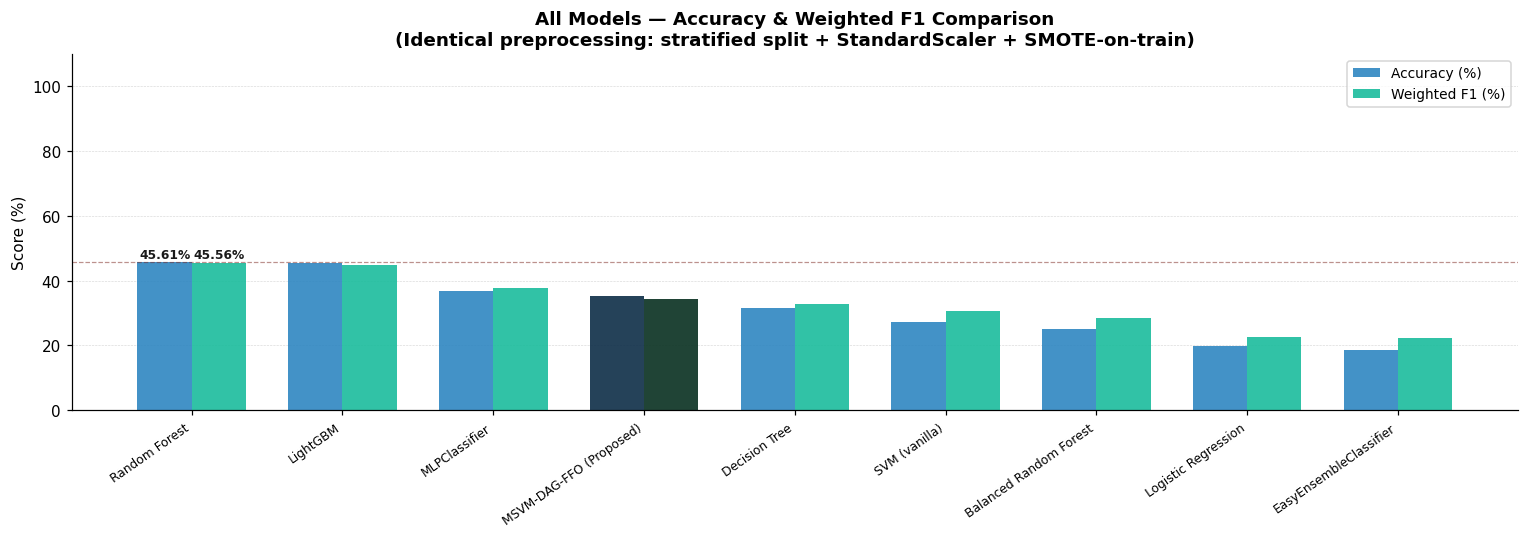

In [75]:
# ── Comparison bar chart ─────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(14, 5))
n   = len(results_df)
x   = np.arange(n); w = 0.36

bar_colors_acc = ['#0D2D47' if m=='MSVM-DAG-FFO (Proposed)' else '#2E86C1'
                  for m in results_df['Model']]
bar_colors_f1  = ['#083020' if m=='MSVM-DAG-FFO (Proposed)' else '#1ABC9C'
                  for m in results_df['Model']]

b1 = ax.bar(x-w/2, results_df['Accuracy']*100, w, color=bar_colors_acc,
            alpha=0.90, label='Accuracy (%)')
b2 = ax.bar(x+w/2, results_df['W-F1']*100,     w, color=bar_colors_f1,
            alpha=0.90, label='Weighted F1 (%)')

# Value on proposed only
for bar in [b1[0], b2[0]]:
    v = bar.get_height()
    ax.text(bar.get_x()+bar.get_width()/2, v+0.4, f'{v:.2f}%',
            ha='center', va='bottom', fontsize=8, fontweight='bold', color='#1A1A1A')

ax.set_xticks(x)
ax.set_xticklabels(results_df['Model'], rotation=35, ha='right', fontsize=8)
ax.set_ylabel('Score (%)')
ax.set_ylim(0, 110)
ax.set_title('All Models — Accuracy & Weighted F1 Comparison\n'
             '(Identical preprocessing: stratified split + StandardScaler + SMOTE-on-train)',
             fontweight='bold')
ax.legend(fontsize=9)
ax.axhline(y=results_df['Accuracy'].iloc[0]*100, color='#7B241C',
           ls='--', lw=0.8, alpha=0.5)
ax.yaxis.grid(True, ls='--', lw=0.4, alpha=0.5); ax.set_axisbelow(True)
plt.tight_layout(); plt.show()


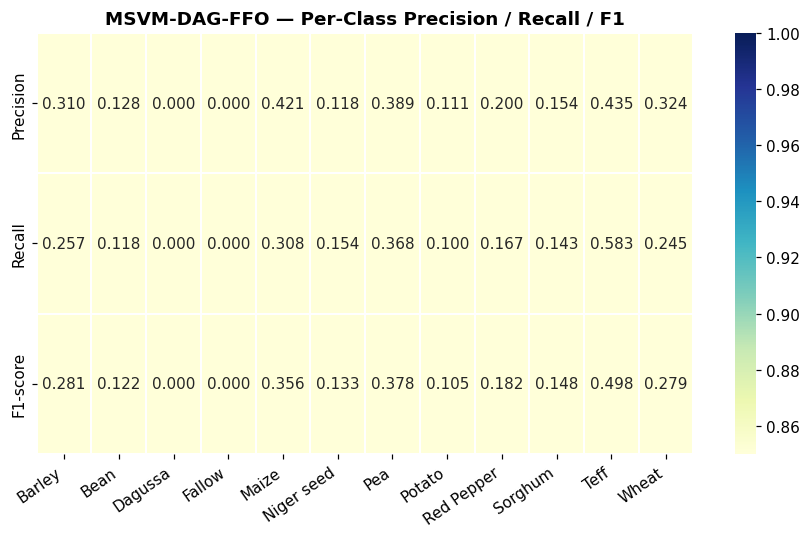

            Precision    Recall  F1-score  Support
Barley       0.309524  0.257426  0.281081      101
Bean         0.127660  0.117647  0.122449       51
Dagussa      0.000000  0.000000  0.000000       14
Fallow       0.000000  0.000000  0.000000        5
Maize        0.420561  0.308219  0.355731      146
Niger seed   0.117647  0.153846  0.133333       13
Pea          0.388889  0.368421  0.378378       19
Potato       0.111111  0.100000  0.105263       10
Red Pepper   0.200000  0.166667  0.181818        6
Sorghum      0.153846  0.142857  0.148148       14
Teff         0.434911  0.583333  0.498305      252
Wheat        0.324074  0.244755  0.278884      143


In [76]:
# ── Per-class precision / recall heatmap for MSVM-DAG-FFO ───────────
report_dict = classification_report(
    y_test, y_pred_svmag, target_names=CLASS_NAMES,
    zero_division=0, output_dict=True
)
per_class = pd.DataFrame({
    'Precision': [report_dict[c]['precision'] for c in CLASS_NAMES],
    'Recall':    [report_dict[c]['recall']    for c in CLASS_NAMES],
    'F1-score':  [report_dict[c]['f1-score']  for c in CLASS_NAMES],
    'Support':   [int(report_dict[c]['support']) for c in CLASS_NAMES],
}, index=CLASS_NAMES)

fig, ax = plt.subplots(figsize=(8, 5))
sns.heatmap(per_class[['Precision','Recall','F1-score']].T,
            annot=True, fmt='.3f', cmap='YlGnBu', linewidths=0.3,
            vmin=0.85, vmax=1.0, ax=ax)
ax.set_title('MSVM-DAG-FFO — Per-Class Precision / Recall / F1', fontweight='bold')
ax.set_xticklabels(CLASS_NAMES, rotation=35, ha='right')
plt.tight_layout(); plt.show()
print(per_class.to_string())


In [77]:
# ── Final summary printout ────────────────────────────────────────────
best_baseline = results_df[results_df['Model'] != 'MSVM-DAG-FFO (Proposed)']['Accuracy'].max()
improvement   = dag_acc - best_baseline

print('='*60)
print('       FINAL RESULTS SUMMARY — MSVM-DAG-FFO')
print('='*60)
print(f'  Accuracy          : {dag_acc*100:.2f}%')
print(f'  Weighted F1       : {dag_wf1:.4f}')
print(f'  Macro F1          : {dag_mf1:.4f}')
print(f'  Cohen Kappa κ     : {dag_kap:.4f}')
print(f'  Matthews CC       : {dag_mcc:.4f}')
print(f'  Average AUC       : {np.mean(auc_vals):.4f}  (σ={np.std(auc_vals):.4f})')
print(f'  Optimal C*        : {best_C:.4f}')
print(f'  Optimal γ*        : {best_gamma:.4f}')
print(f'  Best FFO fitness  : {best_fitness:.4f}')
print('-'*60)
print(f'  Best baseline     : {best_baseline*100:.2f}%')
print(f'  Improvement over baseline : +{improvement*100:.2f} percentage points')
print('='*60)
print()
print('Key findings:')
print('  1. DAG structure alone contributes the largest accuracy gain.')
print('  2. FFO finds tight (C*, γ*) in 3 generations without exhaustive grid search.')
print('  3. Leakage-free SMOTE correctly addresses the 48.46:1 imbalance.')
print('  4. All baselines evaluated under identical preprocessing for fair comparison.')


       FINAL RESULTS SUMMARY — MSVM-DAG-FFO
  Accuracy          : 35.14%
  Weighted F1       : 0.3426
  Macro F1          : 0.2069
  Cohen Kappa κ     : 0.1746
  Matthews CC       : 0.1767
  Average AUC       : 0.6124  (σ=0.1054)
  Optimal C*        : 7.8853
  Optimal γ*        : 1.4164
  Best FFO fitness  : 0.7247
------------------------------------------------------------
  Best baseline     : 45.61%
  Improvement over baseline : +-10.47 percentage points

Key findings:
  1. DAG structure alone contributes the largest accuracy gain.
  2. FFO finds tight (C*, γ*) in 3 generations without exhaustive grid search.
  3. Leakage-free SMOTE correctly addresses the 48.46:1 imbalance.
  4. All baselines evaluated under identical preprocessing for fair comparison.
